# K-means

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Mašinsko učenje/Klasterizacija/klastering_ds.csv")

In [ ]:
# Prebrojavanje duplikata
#duplicate_counts = data.duplicated(keep=False)
#print("Broj duplih redova:", duplicate_counts)

## Klastering tendencija

In [ ]:
!pip install pyclustertend

In [ ]:
from pyclustertend import hopkins

print("Klaster tendencija za originalni skup podataka: ", hopkins(data, len(data)))

/usr/local/lib/python3.11/dist-packages/pyclustertend/hopkins.py:60: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  min_data_frame[0], max_data_frame[0], sampling_size
/usr/local/lib/python3.11/dist-packages/pyclustertend/hopkins.py:63: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  min_data_frame[1], max_data_frame[1], sampling_size
/usr/local/lib/python3.11/dist-packages/pyclustertend/hopkins.py:71: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

Klaster tendencija za originalni skup podataka:  0.04738014448374698


## Skaliranje podataka

In [ ]:
scaler = StandardScaler()
data = scaler.fit_transform(data)

## Elbow metoda - određivanje k

In [ ]:
!pip install kneed
from kneed import KneeLocator

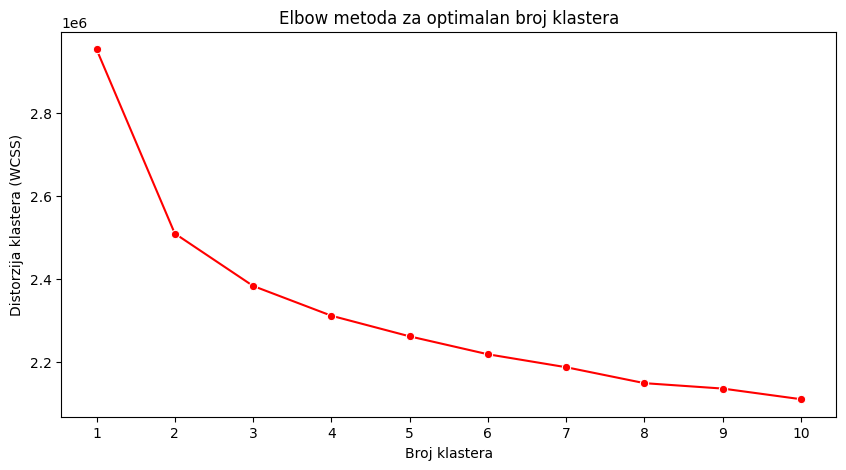

In [ ]:
# Korištenje elbow metode za pronalazak optimalnog broja klastera
from sklearn.cluster import KMeans

wcss = [] # ili distortions
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(data)
    # inertia method returns wcss for that model
    # inertia_ = Sum of squared distances of samples to their closest cluster center
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(10,5))
sns.lineplot(x=range(1, 11), y=wcss, marker='o', color='red')
plt.xticks(range(1, 11, 1))
plt.title('Elbow metoda za optimalan broj klastera')
plt.xlabel('Broj klastera')
plt.ylabel('Distorzija klastera (WCSS)')
plt.show()

In [ ]:
from kneed import KneeLocator

kl = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
kl.elbow

3

## Silueta metod - odabir k

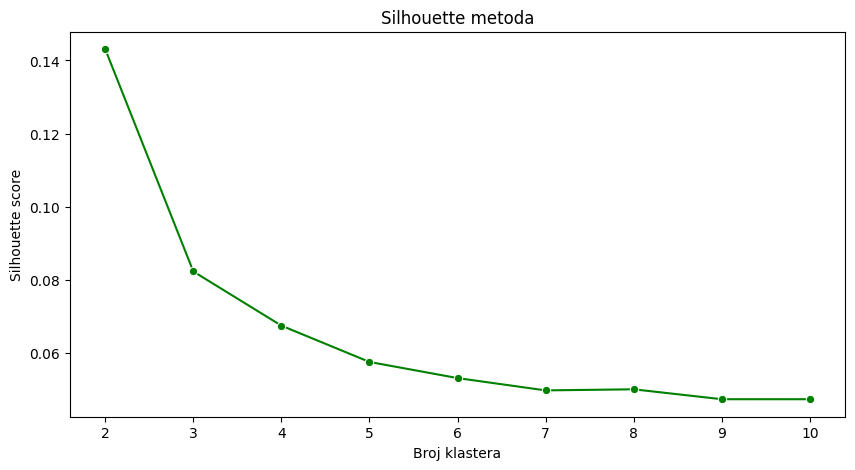

In [ ]:
#Određivanje optimalnog broja klastera pomoću Silhoutte
from sklearn.metrics import silhouette_score

sil = []
Kmax = 10

for k in range(2,Kmax+1):
  kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state = 42)
  y = kmeans.fit(data)
  labels = y.labels_
  s = silhouette_score(data, labels, metric = 'euclidean',  random_state=42) #sample_size=40000,
  sil.append(s)

plt.figure(figsize=(10,5))
sns.lineplot(x=range(2, Kmax+1), y=sil, marker='o', color='green')
plt.xticks(range(2, 11, 1))
plt.title('Silhouette metoda')
plt.xlabel('Broj klastera')
plt.ylabel('Silhouette score')
plt.show()


## Formula

In [ ]:
k = int(np.sqrt(len(data) / 2))
print(f"Procena broja klastera prema formuli sqrt(n/2): {k}")

kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state = 42)
kmeans.fit(data)
print("Distorzija:", kmeans.inertia_)
print(silhouette_score(data, kmeans.labels_, metric = 'euclidean', sample_size=10000, random_state=42))

Procena broja klastera prema formuli sqrt(n/2): 221
Distorzija: 1433959.9324936606
0.034330420354538316


## Kreiranje i treniranje model

In [ ]:
model = KMeans(n_clusters = 2, init = 'k-means++', random_state = 42)
y = model.fit(data)
print(y)


KMeans(n_clusters=2, random_state=42)


In [ ]:
data = pd.DataFrame(data)

In [ ]:
data["Credit_score"] = y.labels_

In [ ]:
data

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,Credit_score
0,-0.218793,1.211763,-0.799220,-0.913275,-0.488691,-1.634567,0.285382,-1.218006,-0.610469,0.134525,...,1.507098,1.466293,1.488794,1.477399,-0.869286,-0.675940,-0.671286,-0.670618,-0.685079,1
1,-0.218793,0.009075,-0.242388,-2.070356,0.291083,-0.432323,-0.330525,-0.611472,-0.311636,-0.442931,...,1.507098,1.466293,-0.671685,-0.676865,-0.869286,-0.675940,-0.671286,-0.670618,-0.685079,1
2,-0.218793,-0.472000,0.730527,-1.684663,-0.488691,-0.776706,-0.890460,0.197239,-1.972969,-0.785238,...,-0.663527,-0.681992,-0.671685,-0.676865,-0.869286,-0.675940,-0.671286,1.491162,-0.685079,1
3,-0.218793,-0.953075,-0.919588,0.243806,0.291083,0.568221,0.887584,-0.004939,0.970589,2.003819,...,1.507098,-0.681992,1.488794,-0.676865,1.150369,-0.675940,-0.671286,-0.670618,1.459685,0
4,-0.218793,1.211763,-0.794334,1.786581,0.557868,0.924561,0.887584,1.477699,0.768784,-0.262848,...,1.507098,1.466293,-0.671685,1.477399,-0.869286,-0.675940,-0.671286,-0.670618,1.459685,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98433,-1.092029,1.211763,0.804968,0.243806,-0.045891,0.985392,0.984850,1.545091,0.822540,-1.060572,...,-0.663527,1.466293,-0.671685,1.477399,1.150369,1.479422,-0.671286,-0.670618,-0.685079,0
98434,-1.092029,-0.472000,3.350830,1.015194,0.956888,0.858328,0.285382,1.747269,0.525750,0.578036,...,-0.663527,-0.681992,1.488794,1.477399,-0.869286,1.479422,-0.671286,1.491162,-0.685079,0
98435,-1.092029,-0.953075,0.299799,1.786581,-0.045891,0.662449,0.483541,-0.341902,0.456461,2.880423,...,-0.663527,1.466293,1.488794,-0.676865,1.150369,-0.675940,-0.671286,1.491162,-0.685079,0
98436,-1.092029,1.211763,0.751045,-0.913275,-1.103986,-0.173905,0.027788,-0.678865,0.525750,1.024524,...,-0.663527,1.466293,-0.671685,-0.676865,-0.869286,-0.675940,-0.671286,1.491162,-0.685079,1


## Evaluacija modela

In [ ]:
# Broj instanci po klasterima
count = np.bincount(y.labels_)
print(count)

[39988 58450]


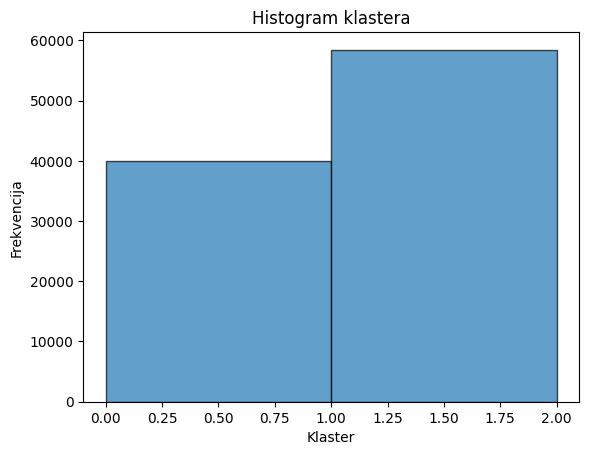

In [ ]:
import matplotlib.pyplot as plt
labels = y.labels_

# Ispis histograma za dodeljene klastere
plt.hist(labels, bins=range(min(labels), max(labels) + 2), edgecolor='black', alpha=0.7)
plt.title("Histogram klastera")
plt.xlabel("Klaster")
plt.ylabel("Frekvencija")
plt.show()

In [ ]:
# Procjena kohezivnosti klastera

print("Ukupni WSS:", y.inertia_)

# Predviđanje klastera za svaki podatak
labels = y.labels_

# Centroidi klastera
centroids = y.cluster_centers_

# Funkcija za izračunavanje WSS za svaki klaster
def calculate_wss_per_cluster(data, centroids):
  wss_per_cluster = []
  for i in range(len(centroids)):
    cluster_data = data[data["Credit_score"] == i].drop(columns="Credit_score")
    wss = 0
    for red in cluster_data.itertuples():
      distance = 0

      for j in range(len(centroids[i])):
        distance += (red[j+1] - centroids[i][j]) ** 2
      wss += distance
    wss_per_cluster.append(wss)

  return wss_per_cluster

# Izračunavanje WSS za svaki klaster
wss_per_cluster = calculate_wss_per_cluster(data, centroids)

# Ispis WSS za svaki klaster
for i, wss in enumerate(wss_per_cluster):
    print(f"WSS za klaster {i}: {wss}")


Ukupni WSS: 2508810.3879551548
WSS za klaster 0: 1055400.9556976897
WSS za klaster 1: 1453409.432257469


In [ ]:
# Procjena separacija - BSS


# Predviđanje klastera za svaki podatak
labels = y.labels_

# Centroidi klastera
centroids = y.cluster_centers_

# Funkcija za izračunavanje BSS za svaki klaster
def calculate_bss_per_cluster(data, centroids):
  m = data.iloc[:, :-1].mean()

  bss_per_cluster = []
  for i in range(len(centroids)):
    cluster_data = data[data["Credit_score"] == i].drop(columns="Credit_score")
    cluster_mean = cluster_data.mean()
    bss_per_cluster.append(len(cluster_data) * ((m - cluster_mean)**2))
  return bss_per_cluster

# Izračunavanje WSS za svaki klaster
bss_per_cluster = calculate_bss_per_cluster(data, centroids)

# Ispis BSS za svaki klaster
bss_ukupno = 0
for i, bss in enumerate(bss_per_cluster):
  s = np.sum(bss)
  bss_ukupno += s
  print(f"BSS za klaster {i}: {s}")

print("BSS za sve klase", bss_ukupno)

BSS za klaster 0: 263832.15680050204
BSS za klaster 1: 180498.20848825443
BSS za sve klase 444330.36528875644


In [ ]:
# Procjena klastering strukture pomoću Silhoutte scora
from sklearn.metrics import silhouette_score

s = silhouette_score(data.iloc[:,:-1], labels, metric = 'euclidean', random_state=42) #sample_size=25000
print("Silhoutte score:", s)


Silhoutte score: 0.14308594920122492


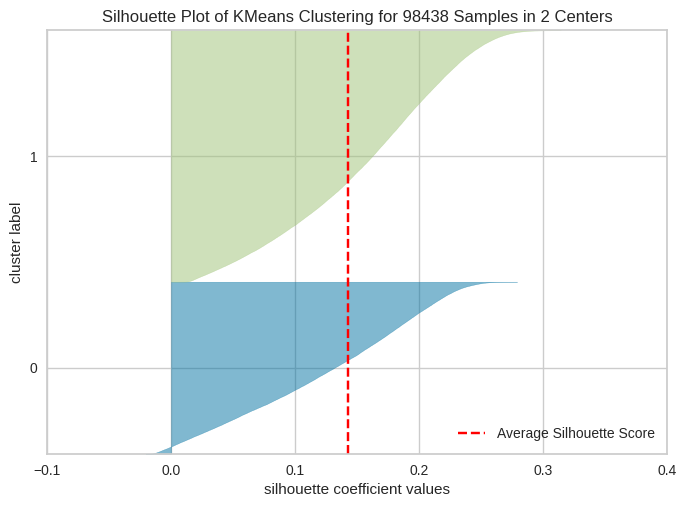

0.14308594920122492


In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
visualizer = SilhouetteVisualizer(y, colors='yellowbrick')
visualizer.fit(data.iloc[:,:-1])        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure
print(visualizer.silhouette_score_)